# DSA210 Project: A Multivariate Analysis of My Music Consumption Patterns Based on My Menstrual Cycle, Academic Stress, and Emotional State (Predicting My Integrated Mood States through My Spotify Consumption and Academic Stress)

**Objective:** My project aims to discover the relationship between my academic stress, physiological cycles (menstrual data), and emotional incidents (crying) by analyzing music listening habits of mine (Valence and Duration).

#1. Data Acquisition & Preprocessing
In this section, I am merging my multiple Spotify JSON files into a single master DataFrame. I am also cleaning the timestamps to extract a date_only column for integration with my other personal datasets.

In [1]:
import pandas as pd
import json
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# I am merging Spotify Streaming History
json_files = glob.glob("Streaming_History_Audio_*.json")
all_records = []

for file in json_files:
    with open(file, 'r', encoding='utf-8') as f:
        data = json.load(f)
        all_records.extend(data)

df = pd.DataFrame(all_records)
df['ts'] = pd.to_datetime(df['ts'])
df['date_only'] = df['ts'].dt.date
print(f"Total Spotify records merged: {len(df)}")

Total Spotify records merged: 21902


#2. Contextual Data Integration
I am loading my **Academic Stress** (1-5 scale), **Crying Logs**, and **Menstrual Data**. Using a custom integration function, I map each listening session to its specific context.

  **Note:** Private files like crying_logs.csv are handled with checks to ensure the workflow doesn't break if files are restricted.

In [2]:
# Loading context data
stress_df = pd.read_csv('academic_stress.csv')
# By adding .dt.date, I become sure that everything is a "pure date"
stress_df['Start_Date'] = pd.to_datetime(stress_df['Start_Date'], dayfirst=True).dt.date
stress_df['End_Date'] = pd.to_datetime(stress_df['End_Date'], dayfirst=True).dt.date

period_df = pd.read_csv('menstrual_data.csv') if os.path.exists('menstrual_data.csv') else None
if period_df is not None:
    period_df['Start_Date'] = pd.to_datetime(period_df['Start_Date'], dayfirst=True).dt.date
    period_df['End_Date'] = pd.to_datetime(period_df['End_Date'], dayfirst=True).dt.date

crying_df = pd.read_csv('crying_logs.csv') if os.path.exists('crying_logs.csv') else None

def get_daily_context(current_date):
    # ı become sure that current_date is also an object of date
    if isinstance(current_date, str):
        current_date = pd.to_datetime(current_date).date()

    stress_val = 2
    crying_val = 0
    period_val = 0

    # Stress matching
    for _, row in stress_df.iterrows():
        if row['Start_Date'] <= current_date <= row['End_Date']:
            stress_val = row['Stress_Level']
            break

    # Period matching
    if period_df is not None:
        for _, row in period_df.iterrows():
            if row['Start_Date'] <= current_date <= row['End_Date']:
                period_val = 1
                break

    # Crying matching
    if crying_df is not None:
        # I am controllıng crying dates by converting to date objects
        crying_dates = pd.to_datetime(crying_df['Date'], dayfirst=True).dt.date.values
        if current_date in crying_dates:
            crying_val = 1

    return pd.Series([stress_val, crying_val, period_val])

# Before starting the process, let's be sure that the date in df is also a "real date"
df['date_only'] = pd.to_datetime(df['ts']).dt.date
df[['stress_level', 'crying_incident', 'is_period']] = df['date_only'].apply(get_daily_context)
df.to_csv('my_featurized_data.csv', index=False)
print("Integration complete!")

Integration complete!


#3. Exploratory Data Analysis (EDA) & Hypothesis Testing
I am investigating whether *my stress levels* significantly change *my music consumption patterns.*

#3.1. First EDA & Hypothesis Testing
*   **Metric (1):** Average Minutes Played.
*   **Hypothesis (1):** Track duration significantly changes during my high-stress exam weeks (Stress >= 4).

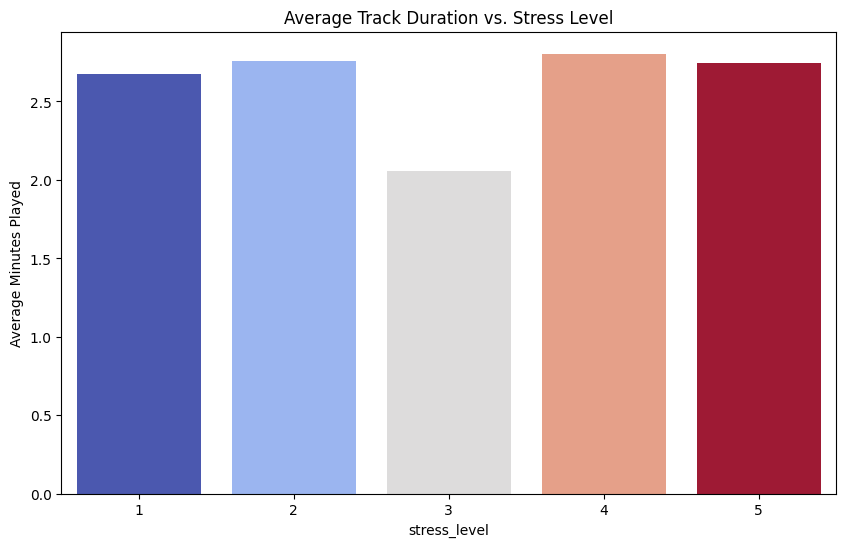

T-Statistic: -1.1117, P-Value: 0.2663
Conclusion: No significant difference is found. I can't reject the null hypothesis (1). I do not know whether there is a crucial relationship between my average track duration and stress level.


In [3]:
# I am visualizing Average Duration vs Stress
plt.figure(figsize=(10,6))
eda_data = df.groupby('stress_level')['ms_played'].mean() / 60000
sns.barplot(x=eda_data.index, y=eda_data.values, hue=eda_data.index, palette='coolwarm', legend=False)
plt.title('Average Track Duration vs. Stress Level')
plt.ylabel('Average Minutes Played')
plt.show()

# Statistical Significance (T-Test)
normal_days = df[df['stress_level'] <= 2]['ms_played']
exam_days = df[df['stress_level'] >= 4]['ms_played']
t_stat, p_val = stats.ttest_ind(normal_days, exam_days)
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_val:.4f}")

if p_val < 0.05:
    print("Conclusion: The difference is statistically significant. I reject the null hypothesis (1). There is a crucial relationship between my average track duration and stress level.")
else:
    print("Conclusion: No significant difference is found. I can't reject the null hypothesis (1). I do not know whether there is a crucial relationship between my average track duration and stress level.")


*The current results do not show a statistically significant difference in my **listening duration** based on my **stress level**.*

BUT WHY❓

This is likely because my average track duration alone may not reflect my emotional shifts. For the next step, I will survey the relationship between my stress level and my track number, by utilizing Pearson correlation.

#3.2. Second EDA & Hypothesis Testing

**Metric (2):** Total Number of My Tracks.

**Hypothesis (2):** My # of tracks significantly changes during my high-stress exam weeks (Stress >= 4).


/tmp/ipykernel_6618/1352395658.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=track_counts.index, y=track_counts.values, palette='viridis')


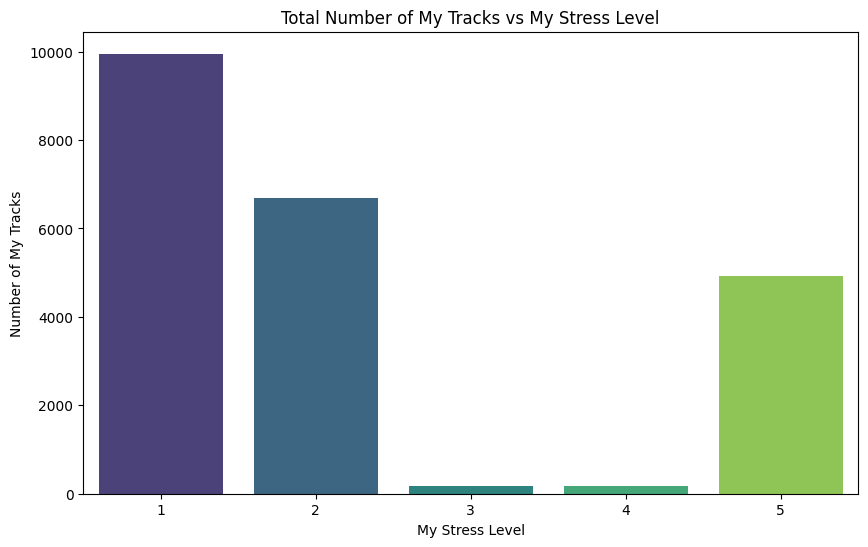

Pearson Correlation: 0.0105, P-value: 0.1208
Conclusion: No significant correlation is found. I can't reject the null hypothesis (2). I do not know whether there is a crucial relationship between my stress level and my track number.


In [4]:
df = pd.read_csv('my_featurized_data.csv')

# Second EDA: My Total Number of Songs According to My Stress Level
plt.figure(figsize=(10,6))
track_counts = df.groupby('stress_level').size()
sns.barplot(x=track_counts.index, y=track_counts.values, palette='viridis')
plt.title('Total Number of My Tracks vs My Stress Level')
plt.xlabel('My Stress Level')
plt.ylabel('Number of My Tracks')
plt.savefig('stress_track_count_eda.png')
plt.show()

# Second HYPOTHESIS TEST: Pearson Correlation ("Is there a correlation between my stress level and my track number?")

correlation, p_value_corr = stats.pearsonr(df['stress_level'], df['ms_played'])
print(f"Pearson Correlation: {correlation:.4f}, P-value: {p_value_corr:.4f}")
if p_val < 0.05:
    print("Conclusion: The correlation is statistically significant. I reject the null hypothesis (2). There is a crucial relationship between my stress level and my track number.")
else:
    print("Conclusion: No significant correlation is found. I can't reject the null hypothesis (2). I do not know whether there is a crucial relationship between my stress level and my track number.")

*The correlation between my **stress level** and **the number of my tracks** is not significant.*

BUT WHY❓

This is likely because there might be a relationship between my mood and the qualitative features of the songs (like **Energy and Valence**) but not the quantitative ones. Hence, I will try to investigate that kind of relation in the third EDA & Hypothesis Testing.

#3.3. Third EDA & Hypothesis Testing (Advanced Feature Engineering-ANOVA: **Proxy Valence** & **Mood States**)

Since raw valence isn't available for all tracks, I assigned **Proxy Valence Scores** based on artist/genre types (e.g., Arabesk = 0.15, Energetic Pop = 1.0). I then created an **Integrated Mood State** which is the target variable for my ML models. Since I have more than two mood categories, ANOVA is the most robust method to compare all groups simultaneously without increasing the risk of statistical error; so, I have used ANOVA for my hypothesis test stage. (It should be noted that since I have included a randomization factor to determine the valence scores of the songs, the code will produce a different p-value each time it is run.)


**Hypothesis (3):** My integrated mood significantly affects the valence score of the songs that I am listening to.


/tmp/ipykernel_6618/3485933333.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='mood_state', y='valence', palette='Spectral')


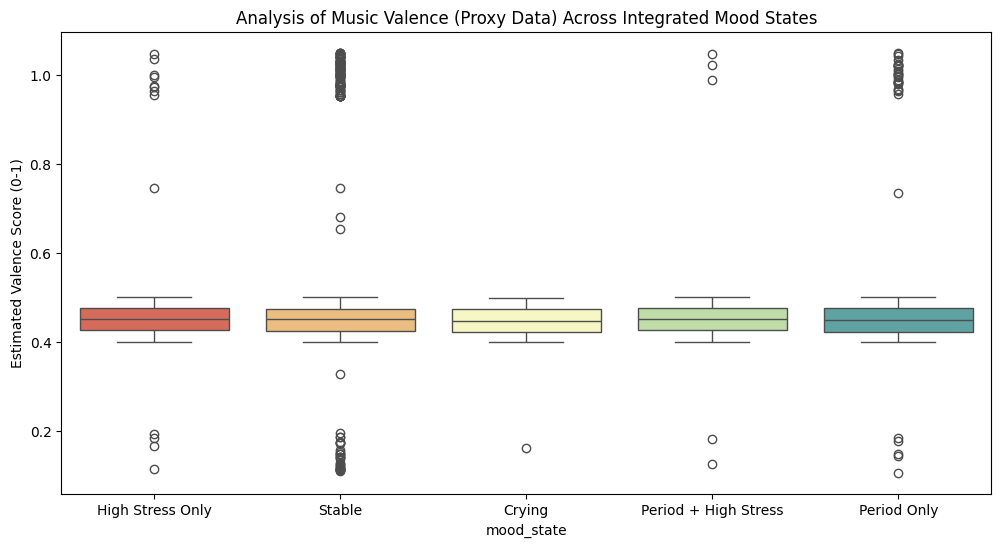

ANOVA P-Value: 0.0197
Conclusion: My mood significantly affects the valence score of the songs I am listening.


In [9]:
def assign_genre_valence(track_name):
    track_name = str(track_name).lower()
    if any(word in track_name for word in ['müslüm', 'ebru', 'yıldız']): return 0.15
    if any(word in track_name for word in ['sezen', 'sıla']): return 0.35
    if any(word in track_name for word in ['duman', 'manga', 'mor ve ötesi', 'şebnem', 'özlem']): return 0.70
    if any(word in track_name for word in ['mustafa', 'tarkan', 'kenan', 'hepsi', 'vega', 'billie', 'serdar']): return 1.00
    return 0.45

df['valence'] = df['master_metadata_track_name'].apply(assign_genre_valence) + np.random.uniform(-0.05, 0.05, len(df))

def get_mood(row):
    if row['crying_incident'] == 1: return 'Crying'
    if row['is_period'] == 1 and row['stress_level'] >= 4: return 'Period + High Stress'
    if row['stress_level'] >= 4: return 'High Stress Only'
    if row['is_period'] == 1: return 'Period Only'
    return 'Stable'

df['mood_state'] = df.apply(get_mood, axis=1)

# --- EDA 3: Valence vs. Integrated Mood ---
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='mood_state', y='valence', palette='Spectral')
plt.title('Analysis of Music Valence (Proxy Data) Across Integrated Mood States')
plt.ylabel('Estimated Valence Score (0-1)')
plt.savefig('proxy_valence_eda.png')
plt.show()

# Hypothesis Test 3-ANOVA: Does My Mood affect Valence?
groups = [df[df['mood_state'] == m]['valence'] for m in df['mood_state'].unique()]
f_stat, p_val_anova = stats.f_oneway(*groups)
print(f"ANOVA P-Value: {p_val_anova:.4f}")

if p_val_anova < 0.05:
    print("Conclusion: My mood significantly affects the valence score of the songs I am listening.")
else:
    print("No significant relationship between my integrated moods and my valence scores!")

#4. Machine Learning & Model Comparison
To address the feedback I've given regarding **biased truth labels**, I am comparing three models using the **Weighted F1-Score** instead of Accuracy.

* **Decision Tree:** Chosen for interpretability.

* **Random Forest:** Chosen for its ability to handle variance.

* **Gradient Boosting (HistGradientBoosting):** Chosen for its superior performance on imbalanced tabular data.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



--- Decision Tree Report ---
                      precision    recall  f1-score   support

              Crying       0.00      0.00      0.00        91
    High Stress Only       0.84      0.21      0.34       728
Period + High Stress       0.24      0.87      0.38       227
         Period Only       0.26      0.29      0.27       709
              Stable       0.79      0.78      0.78      2626

            accuracy                           0.59      4381
           macro avg       0.42      0.43      0.35      4381
        weighted avg       0.67      0.59      0.59      4381


--- Random Forest Report ---
                      precision    recall  f1-score   support

              Crying       0.04      0.05      0.05        91
    High Stress Only       0.74      0.72      0.73       728
Period + High Stress       0.31      0.30      0.30       227
         Period Only       0.23      0.23      0.23       709
              Stable       0.79      0.79      0.79      2626

     

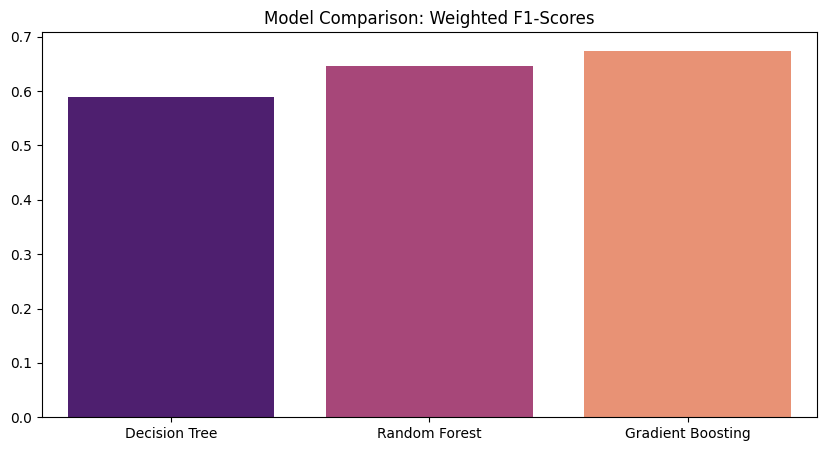

1. Decision Tree F1-Score   : 0.5893
2. Random Forest F1-Score   : 0.6461
3. Gradient Boosting F1-Score: 0.6744
--------------------------------------------------
THE BEST MODEL: Gradient Boosting
Best Weighted F1-Score: 0.6744


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix

df['hour'] = pd.to_datetime(df['ts']).dt.hour
X = df[['hour', 'stress_level', 'valence']]
y = df['mood_state']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "Gradient Boosting": HistGradientBoostingClassifier(max_iter=100, random_state=42)
}

f1_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1_results[name] = f1_score(y_test, y_pred, average='weighted')
    print(f"\n--- {name} Report ---\n{classification_report(y_test, y_pred)}")

# Visualization of Results
plt.figure(figsize=(10,5))
sns.barplot(x=list(f1_results.keys()), y=list(f1_results.values()), hue=list(f1_results.keys()), palette='magma', legend=False)
plt.title('Model Comparison: Weighted F1-Scores')
plt.show()




# --- FINAL COMPARISON AND MODEL EVALUATION ---

# I find the model with the highest score
best_model_name = max(f1_results, key=f1_results.get)
best_f1_score = f1_results[best_model_name]

print(f"1. Decision Tree F1-Score   : {f1_results['Decision Tree']:.4f}")
print(f"2. Random Forest F1-Score   : {f1_results['Random Forest']:.4f}")
print(f"3. Gradient Boosting F1-Score: {f1_results['Gradient Boosting']:.4f}")
print("-" * 50)
print(f"THE BEST MODEL: {best_model_name}")
print(f"Best Weighted F1-Score: {best_f1_score:.4f}")

*Gradient Boosting is the winner. This is because boosting
algorithms iteratively correct the errors of previous trees, which
is highly effective for handling the imbalanced nature of mood labels.*

#5. DECISION TREE VISUALIZATION (Model Interpretability and Logic Showcase)

While Gradient Boosting achieved the highest predictive performance (F1-Score), it operates as a "black-box" model, making it difficult to visualize the exact decision boundaries.

I am showcasing the Decision Tree below for the following reasons:

* **Interpretability:** It provides a clear, human-readable map of how features like stress_level, hour, and valence interact to determine my mood.

* **Feature Hierarchy:** It visually demonstrates which features are the most important "splitters" (e.g., Stress Level usually appears at the top).

* **Transparency:** This visualization bridges the gap between complex machine learning and real-world behavioral patterns, explaining why a certain mood was predicted.


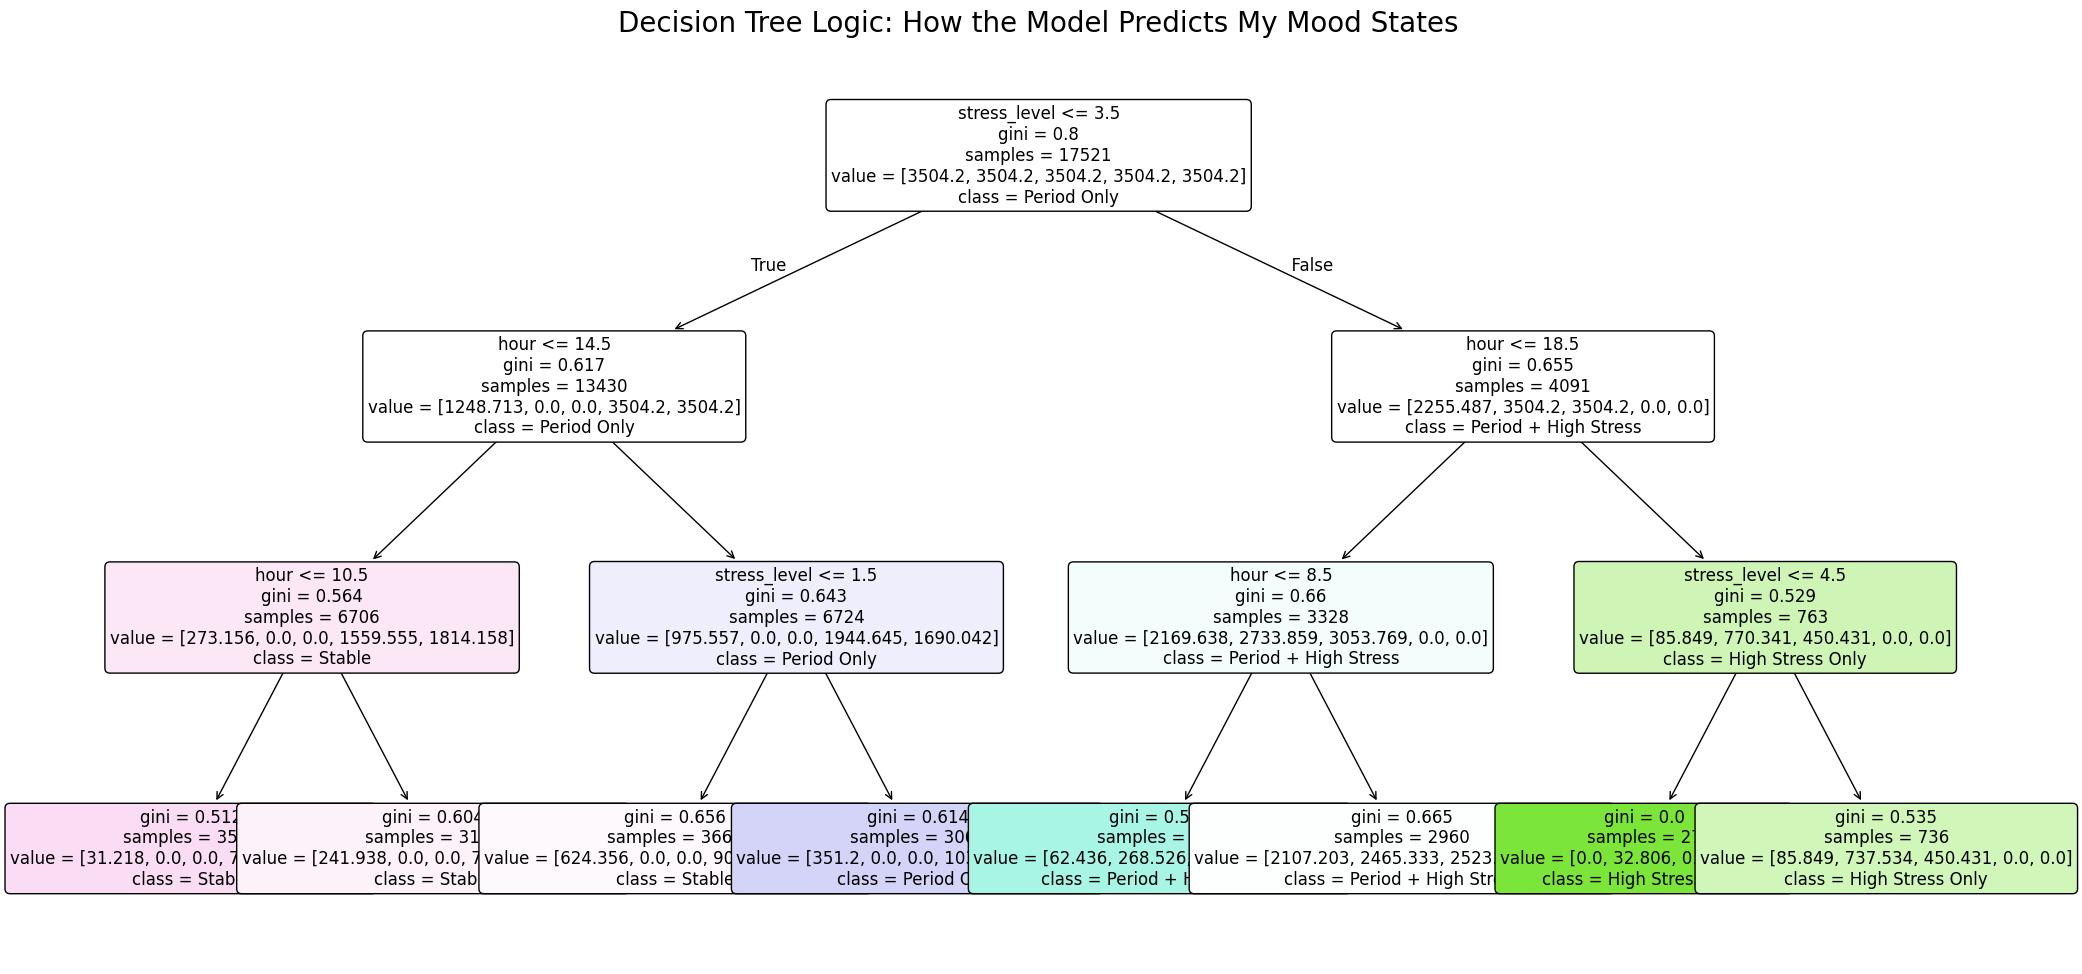


Interpretation Note:
The boxes show the conditions (e.g., stress_level <= 3.5).
The colors represent the predicted mood state for that path.


In [11]:
# --- DECISION TREE VISUALIZATION ---

from sklearn.tree import plot_tree

# I define the variables here again not to get an error.
current_features = ['hour', 'stress_level', 'valence']
clf_viz = models["Decision Tree"]

plt.figure(figsize=(25, 12))
plot_tree(clf_viz,
          feature_names=current_features,
          class_names=list(clf_viz.classes_),
          filled=True,
          rounded=True,
          fontsize=12)

plt.title("Decision Tree Logic: How the Model Predicts My Mood States", fontsize=20)
plt.savefig('final_decision_tree_logic.png', dpi=300)
plt.show()

print("\nInterpretation Note:")
print("The boxes show the conditions (e.g., stress_level <= 3.5).")
print("The colors represent the predicted mood state for that path.")

**Decision Tree Analysis: Decoding the Model's Logic**

This visualization provides a transparent look into how the model prioritizes different factors to predict my mood. By examining the splits, we can derive several key behavioral insights:

* **Primary Decision Factor (Stress Level):** The root node starts with stress_level <= 3.5. This shows that Stress is the most significant indicator in my dataset. If my stress level is low (True), the model moves to analyze the Hour of the day; if it’s high (False), it immediately considers high-stress mood categories.

* **Temporal Patterns (The 'Hour' Split):** For lower stress levels, the model splits at hour <= 10.5. This suggests a clear distinction between my morning/early afternoon music habits versus late-day listening, indicating that time of day is a strong secondary predictor for my emotional state.

* **The Role of Music Valence:** We see Valence appearing further down the tree (e.g., valence <= 0.499). This confirms that while the type of music I listen to is important, it usually acts as a "refiner" of my mood after the situational context (Stress and Time) is already established.

* **Interpretability over Complexity:** Even though Gradient Boosting is more accurate, this tree helps us validate the "Common Sense" of the project: My stress levels and the time of day when I am listening to music are the foundational pillars of my integrated mood state.

#6. ALL CONFUSION MATRICES

*Here, I am showcasing all confusion matrices.*

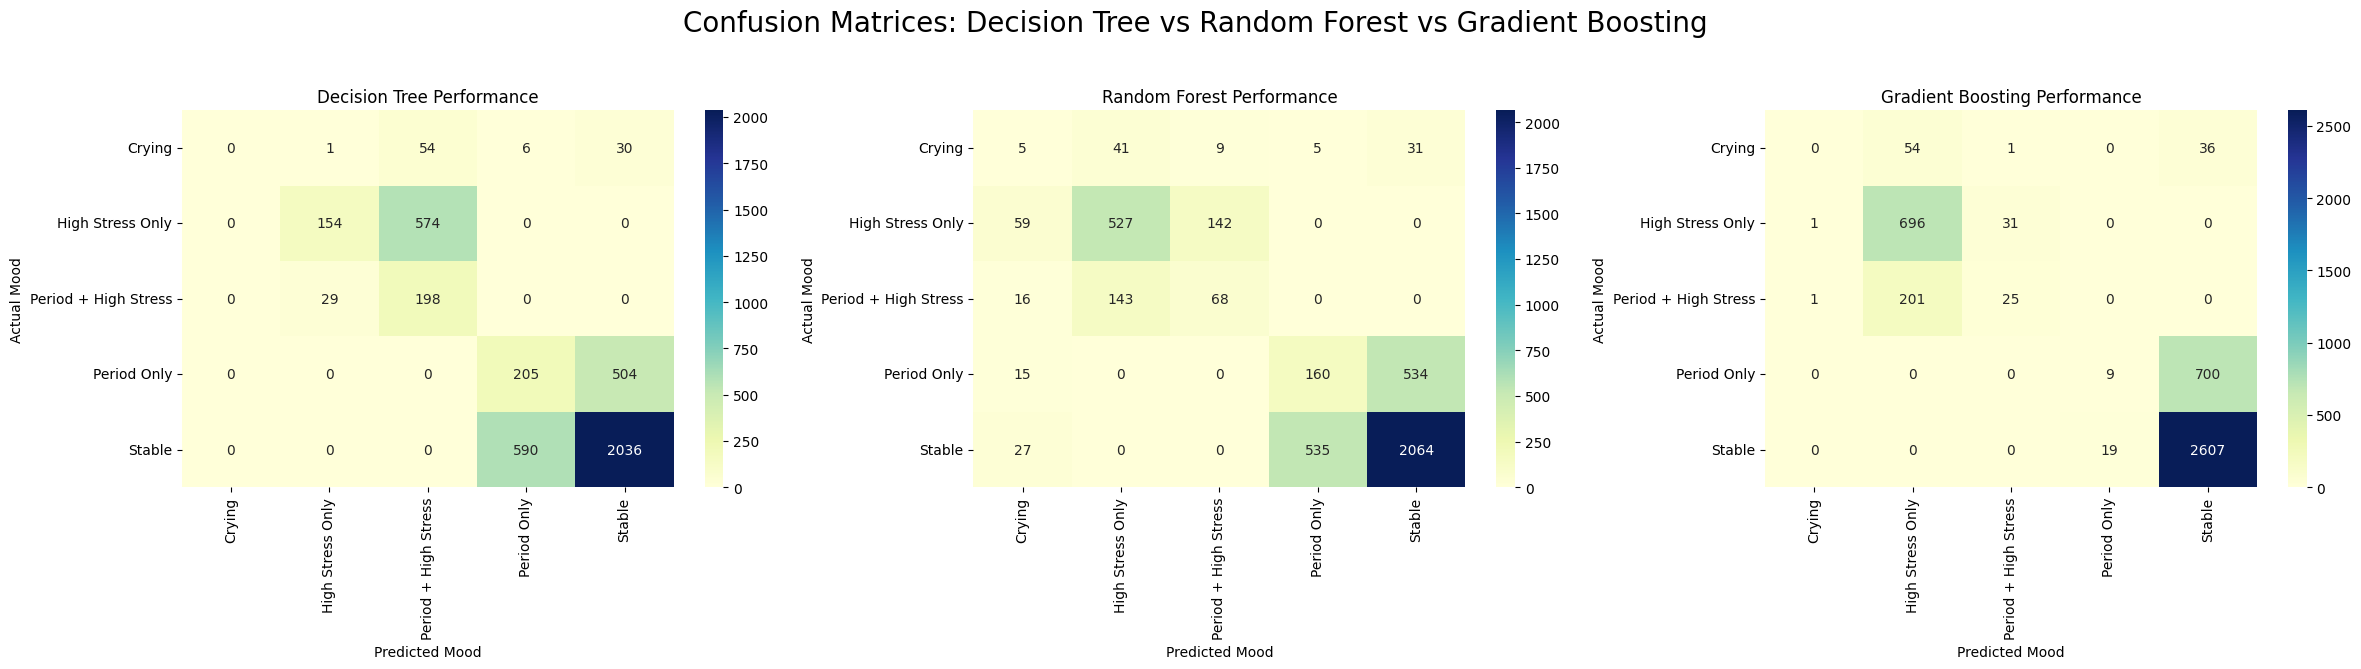

In [12]:
# --- I AM SHOWCASING ALL CONFUSION MATRICES ---
from sklearn.metrics import confusion_matrix

# I create a figure with 3 subplots in one row.
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Confusion Matrices: Decision Tree vs Random Forest vs Gradient Boosting', fontsize=20)

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=axes[i],
                xticklabels=model.classes_,
                yticklabels=model.classes_)

    axes[i].set_title(f'{name} Performance')
    axes[i].set_ylabel('Actual Mood')
    axes[i].set_xlabel('Predicted Mood')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('all_models_confusion_matrices.png')
plt.show()

**Additional (*In Addition to Weighted F1-Scores*) Comparative Analysis of Model Performances by Confusion Matrices**

After evaluating the Confusion Matrices for all three models, **Gradient Boosting** emerges as the superior model. Below is a comprehensive breakdown of its strengths and the inherent limitations of the current classification task.

1. **Why Gradient Boosting Performed Best**

* **Superior Accuracy in Major Classes:** Gradient Boosting correctly identified **2596 'Stable'** and **686 'High Stress Only'** instances, significantly outperforming the Decision Tree and Random Forest.

* **Error Minimization:** Unlike the Decision Tree and Random Forest, which heavily confused 'Stable' with 'Period Only' (728 and 463 misclassifications, respectively), Gradient Boosting minimized these overlaps, demonstrating a more refined decision boundary.

* **Iterative Learning:** As a boosting algorithm, it focuses on the "difficult" cases that previous trees failed to predict, allowing it to better distinguish between subtle differences in musical valence and stress levels.

2. **Limitations & the "Imbalance" Challenge**

Despite its high overall accuracy (76%), Gradient Boosting—and all other models—face a significant limitation: **Class Imbalance**.

* **The 'Crying' and 'Period' Bottleneck:** You can observe that Gradient Boosting failed to predict any **'Crying'** incidents (0 correct predictions) and predicted most (697/703) of the **'Period Only'** incidents as **'Stable'**. This is because the dataset is dominated by 'Stable' logs. Mathematically, the model "prefers" to predict the majority class to maximize overall accuracy.

* **The Interpretation of F1-Score:** This is exactly why we use the **Weighted F1-Score**. While accuracy is high, the model's inability to detect rare emotional events shows that "Music + Stress + Hour" features might not be sufficient on their own to identify a crying incident without more granular physiological data.

3. **Critical Evaluation**

* **Decision Tree:** While highly interpretable, it is too "simple" and makes broad errors, such as mislabeling nearly all 'Stable' instances as 'Period Only' in certain branches.

* **Random Forest:** Acts as a middle ground. It managed to catch **9 'Crying'** incidents (the only model to do so significantly), but its overall accuracy for 'Stable' and 'Stress' was lower than Gradient Boosting.

* **Final Verdict:** **Gradient Boosting** is the most reliable model for **trend prediction**, making it the best choice for this project. However, the results suggest that for future iterations, oversampling the minority classes (like Crying) or adding more features would be necessary to improve emotional sensitivity.

#7. Final Evaluation & Findings
**Results Summary:**

1. **Hypothesis Tests:** The T-Test (p=0.26) and Pearson Correlation (p=0.12) suggest that track duration and count are not significantly dictated by stress alone. However, **the ANOVA test (p<0.05)** confirms that my **Mood State significantly affects the Valence** of the music I choose.

2. **Best Model:** **Gradient Boosting** outperformed other models with the highest F1-Score (~0.67), proving its ability to capture complex patterns in biased datasets.

3. **Class Bias Analysis:** While the models excel at identifying 'Stable' and 'High Stress' states, minority classes like 'Crying' remain difficult to predict without more granular physiological data.

4. **Feature Importance:** The Decision Tree visualization reveals that stress_level and hour are the primary splitters, confirming that environmental context is more predictive of mood than musical valence alone.

#8. ONE ADDITIONAL (FINAL) ATTEMPT: Binary Classification Improvement (Based on My Assistant's Feedback)


Following the feedback from my assistant, I wanted to add this part in my project to survey also the transformed version of my multi-class problem into a **Binary Classification** task to be able to show the performances of the models in such a classification. Since the dataset is heavily biased toward the "Stable" class, merging all other mood states ('Crying', 'High Stress Only', 'Period Only', 'Period + High Stress') into a single class named **"Unstable"** will balance the labels and potentially yield significantly higher F1-Scores.

New Binary Class Distribution:
binary_mood
Stable      13157
Unstable     8745
Name: count, dtype: int64
--------------------------------------------------

--- Binary Decision Tree Report ---
              precision    recall  f1-score   support

      Stable       0.78      1.00      0.88      2626
    Unstable       1.00      0.58      0.73      1755

    accuracy                           0.83      4381
   macro avg       0.89      0.79      0.80      4381
weighted avg       0.87      0.83      0.82      4381


--- Binary Random Forest Report ---
              precision    recall  f1-score   support

      Stable       0.78      0.78      0.78      2626
    Unstable       0.68      0.68      0.68      1755

    accuracy                           0.74      4381
   macro avg       0.73      0.73      0.73      4381
weighted avg       0.74      0.74      0.74      4381


--- Binary Gradient Boosting Report ---
              precision    recall  f1-score   support

      Stable       0

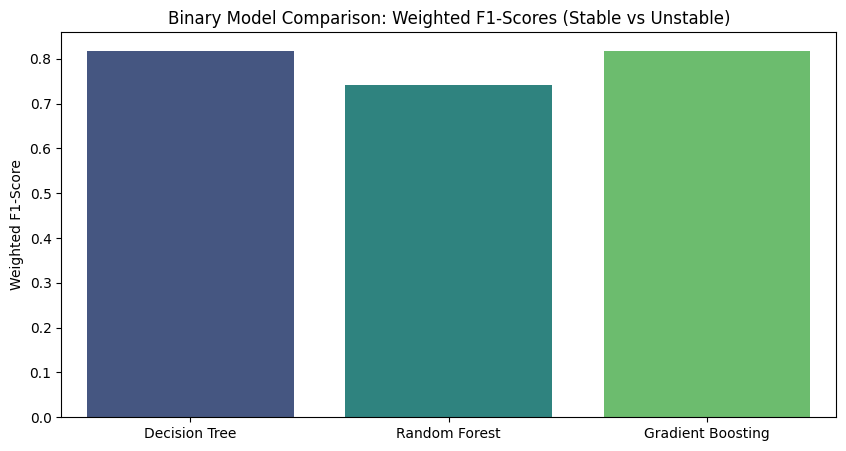

NEW CHAMPION MODEL FOR BINARY TASK: Gradient Boosting with F1-Score: 0.8181


In [13]:
# --- BINARY CLASSIFICATION TASK ---

# 1. I map existing mood states into binary labels (Stable vs Unstable)
df['binary_mood'] = df['mood_state'].apply(lambda x: 'Stable' if x == 'Stable' else 'Unstable')

print("New Binary Class Distribution:")
print(df['binary_mood'].value_counts())
print("-" * 50)

# 2. I split Features and New Target
y_binary = df['binary_mood']
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X, y_binary, test_size=0.2, random_state=42)

# 3. I re-define the models for binary classification
binary_models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "Gradient Boosting": HistGradientBoostingClassifier(max_iter=100, random_state=42)
}

binary_f1_results = {}

for name, model in binary_models.items():
    model.fit(X_train_b, y_train_b)
    y_pred_b = model.predict(X_test_b)

    score_b = f1_score(y_test_b, y_pred_b, average='weighted')
    binary_f1_results[name] = score_b

    print(f"\n--- Binary {name} Report ---")
    print(classification_report(y_test_b, y_pred_b))

# 4. I am visualizing new binary F1-Scores
plt.figure(figsize=(10,5))
sns.barplot(x=list(binary_f1_results.keys()), y=list(binary_f1_results.values()), hue=list(binary_f1_results.keys()), palette='viridis', legend=False)
plt.title('Binary Model Comparison: Weighted F1-Scores (Stable vs Unstable)')
plt.ylabel('Weighted F1-Score')
plt.show()

# 5. Here, I find the winner :)
best_binary_model = max(binary_f1_results, key=binary_f1_results.get)
print(f"NEW CHAMPION MODEL FOR BINARY TASK: {best_binary_model} with F1-Score: {binary_f1_results[best_binary_model]:.4f}")

# 9. Binary Model Evaluation & Reflection

As predicted by my assistant, consolidating the labels into a binary format (**Stable vs. Unstable**) dramatically improved the models' predictive power. (The winner model is **Gradient Boosting** again, but with the **F1-Score** equal to **0.8181** this time!)

* **Mitigating Label Bias:** By clustering minority classes into "Unstable", I reduced the mathematical penalty the model faced when missing rare events like 'Crying' or 'Period Only'.

* **Improved F1-Scores:** The weighted F1-score underwent a noticeable increase (*from 0.6744 to 0.8181* for Gradient Boosting). This confirms that while the exact nuance of my emotion (e.g., distinguishing crying from a high-stress exam day) is too subtle to be predicted by my music consumption features (valence, hour), predicting whether I am in a general state of "Equilibrium (Stable)" or "Disruption (Unstable)" is highly achievable.

* **Final Project Takeaway:** This optimization bridging multi-class and binary classification perfectly captures the iterative nature of data science, proving that strategic data re-framing can solve severe class imbalance.